#  Iris データセット
### Irisの３つの品種を花びら、ガクから学習して予測してみる

<img src ="https://github.com/ueharaLab/datascience_python8/raw/main/iris.png" width="60%">

# Iris datasetからの学習と予測（分類）

<img src ="https://github.com/ueharaLab/datascience_python8/raw/main/iris_ml.png" width="80%">

# 1. Iris datasetの確認
## 一見データセットとは似ても似つかないデータが表示される

In [25]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris_dataset = load_iris()
print(iris_dataset)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

## 1つ1つデータを取り出してみる
- なぜ、１つ１つ取り出せるのか考えてください。
- 教師ラベル、特徴量はそれぞれ以下のコーディングでどれで表示しているか。
- 教師ラベルの名前、特徴量の見出しは何か
- データセットの行列は何行何列か？ 次元数はいくつか。


In [27]:
print("Target names:", iris_dataset['target_names'])

Target names: ['setosa' 'versicolor' 'virginica']


In [28]:
print("Feature names:\n", iris_dataset['feature_names'])

Feature names:
 ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [29]:
print("Type of data:", type(iris_dataset['data']))

Type of data: <class 'numpy.ndarray'>


In [30]:
print("Shape of data:", iris_dataset['data'].shape)

Shape of data: (150, 4)


In [31]:
print("First five rows of data:\n", iris_dataset['data'][:5])

First five rows of data:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [32]:
print("Type of target:", type(iris_dataset['target']))

Type of target: <class 'numpy.ndarray'>


In [33]:
print("Shape of target:", iris_dataset['target'].shape)

Shape of target: (150,)


In [34]:
print("Target:\n", iris_dataset['target'])

Target:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


<img src ="https://github.com/ueharaLab/datascience_python8/raw/main/iris_dataset.png" width="80%">

# 2.訓練データセットとテストデータセットを分割する

---

-  なぜ分割が必要か？
-  (112,4) (112,)は必ず行が一致する。なぜか
-  訓練データの並び方が、上記の教師ラベルの並びと異なるのはなぜか？　ということは、特徴量の並びも同期がとられているはず。

---


<img src ="https://github.com/ueharaLab/datascience_python8/raw/main/iris_split.png" width="80%">

In [2]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(iris_dataset['data'],iris_dataset['target'],random_state=0)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)
print(x_train)
print(y_train)

(112, 4)
(112,)
(38, 4)
(38,)
[[5.9 3.  4.2 1.5]
 [5.8 2.6 4.  1.2]
 [6.8 3.  5.5 2.1]
 [4.7 3.2 1.3 0.2]
 [6.9 3.1 5.1 2.3]
 [5.  3.5 1.6 0.6]
 [5.4 3.7 1.5 0.2]
 [5.  2.  3.5 1. ]
 [6.5 3.  5.5 1.8]
 [6.7 3.3 5.7 2.5]
 [6.  2.2 5.  1.5]
 [6.7 2.5 5.8 1.8]
 [5.6 2.5 3.9 1.1]
 [7.7 3.  6.1 2.3]
 [6.3 3.3 4.7 1.6]
 [5.5 2.4 3.8 1.1]
 [6.3 2.7 4.9 1.8]
 [6.3 2.8 5.1 1.5]
 [4.9 2.5 4.5 1.7]
 [6.3 2.5 5.  1.9]
 [7.  3.2 4.7 1.4]
 [6.5 3.  5.2 2. ]
 [6.  3.4 4.5 1.6]
 [4.8 3.1 1.6 0.2]
 [5.8 2.7 5.1 1.9]
 [5.6 2.7 4.2 1.3]
 [5.6 2.9 3.6 1.3]
 [5.5 2.5 4.  1.3]
 [6.1 3.  4.6 1.4]
 [7.2 3.2 6.  1.8]
 [5.3 3.7 1.5 0.2]
 [4.3 3.  1.1 0.1]
 [6.4 2.7 5.3 1.9]
 [5.7 3.  4.2 1.2]
 [5.4 3.4 1.7 0.2]
 [5.7 4.4 1.5 0.4]
 [6.9 3.1 4.9 1.5]
 [4.6 3.1 1.5 0.2]
 [5.9 3.  5.1 1.8]
 [5.1 2.5 3.  1.1]
 [4.6 3.4 1.4 0.3]
 [6.2 2.2 4.5 1.5]
 [7.2 3.6 6.1 2.5]
 [5.7 2.9 4.2 1.3]
 [4.8 3.  1.4 0.1]
 [7.1 3.  5.9 2.1]
 [6.9 3.2 5.7 2.3]
 [6.5 3.  5.8 2.2]
 [6.4 2.8 5.6 2.1]
 [5.1 3.8 1.6 0.2]
 [4.8 3.4 1.6 0.2]
 

## データ分割の重要構文
---
```python

x_train,x_test,y_train,y_test = train_test_split(特徴量,教師ラベル,random_state=0) 分割する際に、シャッフルしている！

```
**x_train : 訓練特徴量**  
**x_test : テスト特徴量**  
**y_train : 教師ラベル**  
**y_test : テストデータの教師ラベル** -> 何のためにあるか？

---



# 3. Iris データセットを教師あり機械学習で学習・予測する


---
- ### 学習（訓練）：上記のデータセットを機械学習で学習し、irisの3品種を分類するルール（特徴量の違い）を見つけ出す
- ### 分類（予測） : ラベル（品種）が不明の特徴量を入力すると3品種のうちのどれかを分類する
---



### 3.1 学習
1. どこで訓練データを入力しているか
2. 学習はどこで行われているか


In [30]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

iris_dataset = load_iris()
X_train,x_test,Y_train,y_test = train_test_split(iris_dataset['data'],iris_dataset['target'],random_state=0)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=1)

### 3.2 予測
- テストデータは、np.array[[  ]]　つまり、行列になっていることに注意（[[  ]]は2次元配列を意味する）
- 今のところ、テストデータは１つだが、2つにして予測してみてください。


In [31]:
X_new = np.array([[5, 2.9, 4.6, 1.7]])
print("X_new.shape:", X_new.shape)
prediction = knn.predict(X_new)
print("Prediction:", prediction)
print("Predicted target name:",
       iris_dataset['target_names'][prediction])

X_new.shape: (1, 4)
Prediction: [2]
Predicted target name: ['virginica']


<img src ="https://github.com/ueharaLab/datascience_python8/raw/main/iris_predict.png" width="60%">

<img src ="https://github.com/ueharaLab/datascience_python8/raw/main/iris_eval.png" width="60%">

### 　3.3 テストデータにもとづく予測性能の評価
#### 機械学習の性能とはテストデータの当てはまり精度である（訓練データの当てはまりではない）

- y_pred と y_test からどのように性能評価できるか。手計算してみよ。
- 手計算の結果は、knn.scoreと一致するはず

In [35]:
y_pred = knn.predict(x_test)
print("Test set predictions:\n", y_pred)
print("Test set True labels:\n", y_test)
print("Test set score: {:.2f}".format(knn.score(x_test, y_test)))

Test set predictions:
 [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]
Test set True labels:
 [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1]
Test set score: 0.97


<img src ="https://github.com/ueharaLab/datascience_python8/raw/main/iris_eval2.png" width="60%">

# 最もシンプルな機械学習モデル

<img src ="https://github.com/ueharaLab/datascience_python8/raw/main/iris_knn.png" width="80%">

# ハイパーパラメータを変えてK最近傍法を実行する
1. **上記の解説によれれば、評価結果がことなってくるはず**
2. **どこを変えるとよいかを突き止めてk=50で実行せよ**

In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

iris_dataset = load_iris()
X_train,x_test,Y_train,y_test = train_test_split(iris_dataset['data'],iris_dataset['target'],random_state=0)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, Y_train)
y_pred = knn.predict(x_test)
print("Test set predictions:\n", y_pred)
print("Test set True labels:\n", y_test)
print("Test set score: {:.2f}".format(knn.score(x_test, y_test)))

Test set predictions:
 [2 1 0 2 0 2 0 2 2 1 2 1 1 1 1 0 1 1 0 0 1 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]
Test set True labels:
 [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1]
Test set score: 0.89


<img src ="https://github.com/ueharaLab/datascience_python8/raw/main/iris_conlusion.png" width="60%">

## 超重要！

**インスタンス化でつけられた変数名(knn)を、その後の学習・予測に使っている。つまり変数の参照関係がある**


```python
knn = KNeighborsClassifier(n_neighbors=1)　機械学習の実行準備（インスタンス化）
knn.fit(X_train, Y_train)　学習
y_pred = knn.predict(x_test)　予測
```

# インスタンス化とは？

<img src ="https://github.com/ueharaLab/datascience_python8/raw/main/iris_class.png" width="60%">

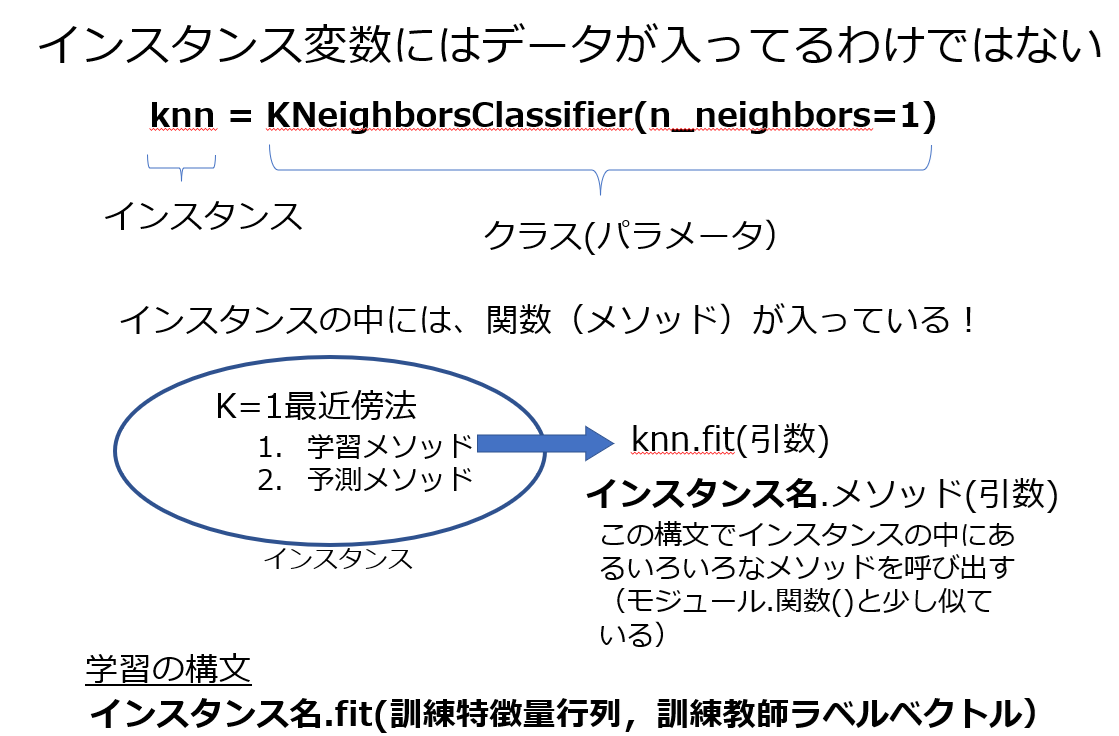

## 複数のハイパーパラメータでKNNを同時に実行する（演習）
異なるインスタンスを作れば、同時に学習・実行できるはず
```python
knn1 = KNeighborsClassifier(n_neighbors=1)
knn100 = KNeighborsClassifier(n_neighbors=100)
```

以下のプログラムに K=1 k=100 にもとづく学習、予測が同時に実行できるように2種類のインスタンスを作成して、予測精度をそれぞれ表示せよ

In [8]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import numpy as np


iris_dataset = load_iris()
X_train,x_test,Y_train,y_test = train_test_split(iris_dataset['data'],iris_dataset['target'],random_state=0)


KNeighborsClassifier(n_neighbors=1)
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1]
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]
test set predictions:
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]
Test set score:0.97
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1]
[2 2 0 2 0 2 0 2 2 2 2 2 2 2 2 0 2 2 0 0 2 2 0 0 2 0 0 2 0 0 2 2 0 2 2 1 0
 2]
test set predictions:
[2 2 0 2 0 2 0 2 2 2 2 2 2 2 2 0 2 2 0 0 2 2 0 0 2 0 0 2 0 0 2 2 0 2 2 1 0
 2]
Test set score:0.61


<img src ="https://github.com/ueharaLab/datascience_python8/raw/main/iris_learning.png" width="80%">